Generating toy data...

Fitting Probabilistic PCA...
Step 0: loss = 1318.7903
Step 500: loss = 1129.1438
Step 1000: loss = 1110.7561
Step 1500: loss = 1108.7678

Fitting standard PCA for comparison...

PPCA Reconstruction MSE: 1.5063
PPCA Noise variance (σ²): 1.8314


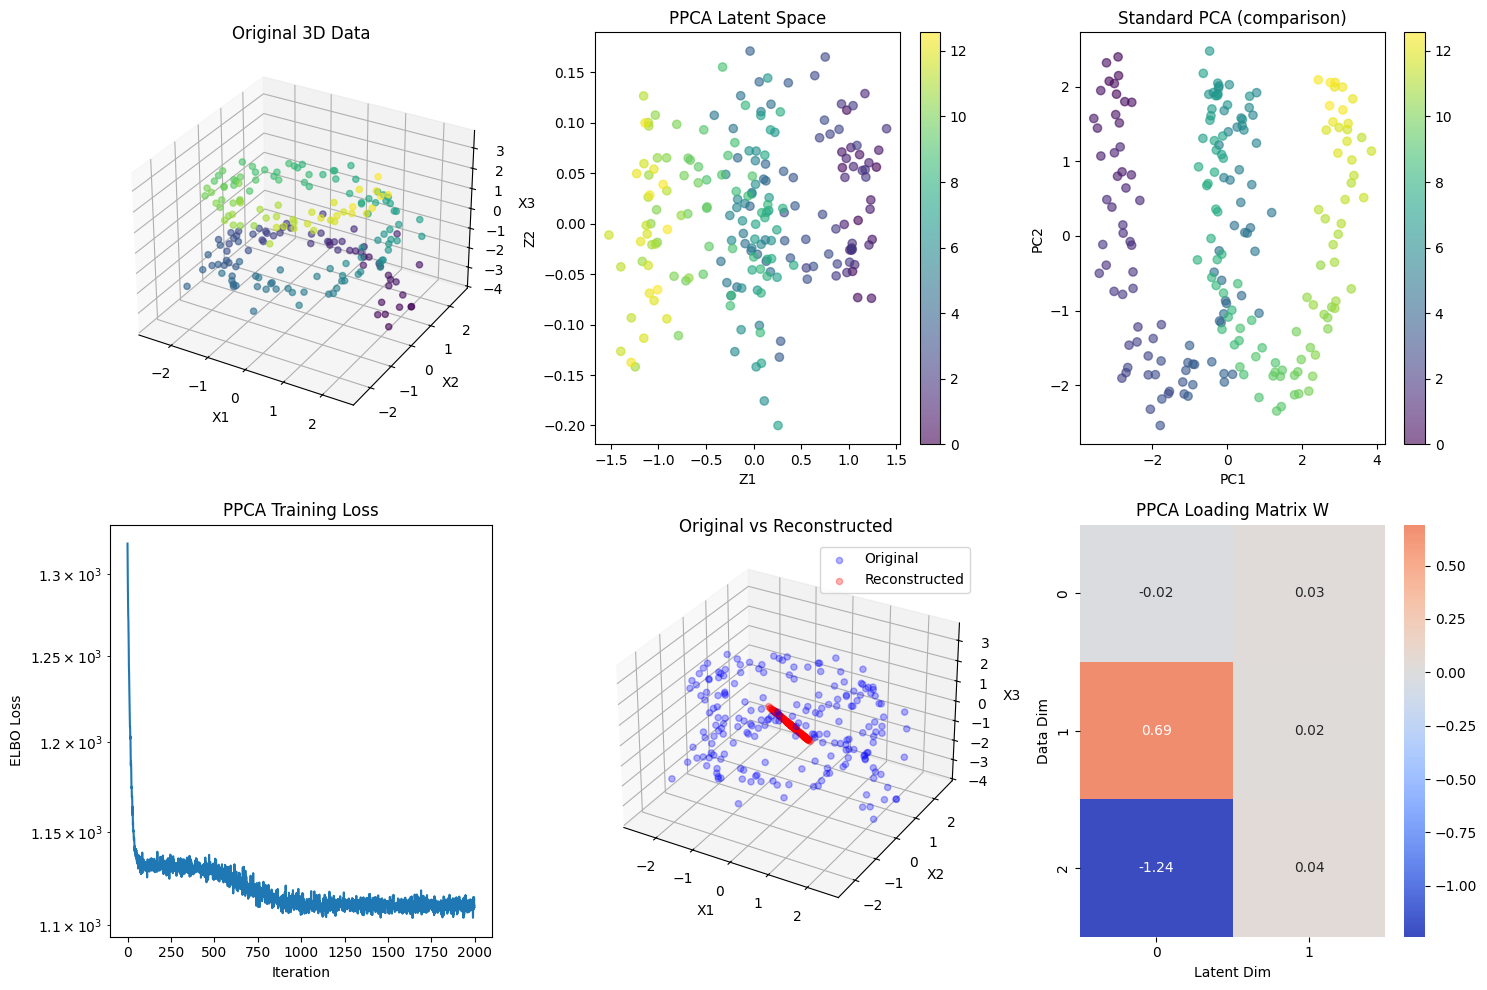


Fitted PPCA Parameters:
Mean μ: [-0.00432751 -0.00309069  0.00056626]
Loading matrix W:
[[-0.01795799  0.0339705 ]
 [ 0.6905869   0.02024605]
 [-1.238769    0.04158091]]
Noise std σ: 1.3533

Standard PCA explained variance ratio: [0.52294687 0.2744786 ]


In [1]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
pyro.set_rng_seed(42)

class ProbabilisticPCA:
    def __init__(self, data_dim, latent_dim):
        """
        Initialize Probabilistic PCA model
        
        Args:
            data_dim: Dimension of observed data
            latent_dim: Dimension of latent space
        """
        self.data_dim = data_dim
        self.latent_dim = latent_dim
        
        # Initialize parameters
        self.W = torch.randn(data_dim, latent_dim) * 0.1
        self.mu = torch.zeros(data_dim)
        self.sigma = torch.tensor(1.0)
        
    def model(self, data):
        """
        PPCA generative model
        
        p(x|z) = N(x | Wz + μ, σ²I)
        p(z) = N(z | 0, I)
        """
        n_samples = data.shape[0]
        
        # Register parameters
        W = pyro.param("W", self.W)
        mu = pyro.param("mu", self.mu)
        sigma = pyro.param("sigma", self.sigma, constraint=dist.constraints.positive)
        
        with pyro.plate("data", n_samples):
            # Sample latent variables
            z = pyro.sample("z", dist.Normal(0., 1.).expand([self.latent_dim]).to_event(1))
            
            # Compute mean of observations
            loc = z @ W.t() + mu
            
            # Sample observations
            pyro.sample("obs", dist.Normal(loc, sigma).to_event(1), obs=data)
    
    def guide(self, data):
        """
        Variational posterior q(z|x)
        We use a factorized Gaussian guide
        """
        n_samples = data.shape[0]
        
        # Variational parameters
        z_loc = pyro.param("z_loc", torch.zeros(n_samples, self.latent_dim))
        z_scale = pyro.param("z_scale", torch.ones(n_samples, self.latent_dim),
                           constraint=dist.constraints.positive)
        
        with pyro.plate("data", n_samples):
            pyro.sample("z", dist.Normal(z_loc, z_scale).to_event(1))
    
    def fit(self, data, n_steps=2000, lr=0.01):
        """
        Fit the model using SVI
        """
        pyro.clear_param_store()
        
        # Convert data to tensor
        data_tensor = torch.tensor(data, dtype=torch.float32)
        
        # Setup optimizer and inference
        optimizer = Adam({"lr": lr})
        svi = SVI(self.model, self.guide, optimizer, loss=Trace_ELBO())
        
        # Training loop
        losses = []
        for step in range(n_steps):
            loss = svi.step(data_tensor)
            losses.append(loss)
            
            if step % 500 == 0:
                print(f"Step {step}: loss = {loss:.4f}")
        
        # Store fitted parameters
        self.W_fitted = pyro.param("W").detach().numpy()
        self.mu_fitted = pyro.param("mu").detach().numpy()
        self.sigma_fitted = pyro.param("sigma").item()
        self.z_loc = pyro.param("z_loc").detach().numpy()
        
        return losses
    
    def transform(self, data):
        """
        Transform data to latent space using the fitted model
        """
        # For new data, we would need to run inference again
        # Here we'll use the variational means for the training data
        return self.z_loc
    
    def reconstruct(self, z=None):
        """
        Reconstruct data from latent representation
        """
        if z is None:
            z = self.z_loc
        return z @ self.W_fitted.T + self.mu_fitted


# Generate toy data
def generate_toy_data(n_samples=200, noise_std=0.1):
    """
    Generate 2D data that lies approximately on a 1D manifold
    """
    # Generate points along a curve
    t = np.linspace(0, 4*np.pi, n_samples)
    
    # Create 2D data with structure
    x1 = 2 * np.cos(t) + np.random.normal(0, noise_std, n_samples)
    x2 = 2 * np.sin(t) + np.random.normal(0, noise_std, n_samples)
    x3 = t/2 + np.random.normal(0, noise_std, n_samples)
    
    data = np.column_stack([x1, x2, x3])
    
    # Center the data
    data = data - data.mean(axis=0)
    
    return data, t


# Main execution
if __name__ == "__main__":
    # Generate toy data
    print("Generating toy data...")
    data, t = generate_toy_data(n_samples=200, noise_std=0.3)
    
    # Fit Probabilistic PCA
    print("\nFitting Probabilistic PCA...")
    ppca = ProbabilisticPCA(data_dim=3, latent_dim=2)
    losses = ppca.fit(data, n_steps=2000, lr=0.01)
    
    # Get latent representation
    z_ppca = ppca.transform(data)
    
    # For comparison, fit standard PCA
    print("\nFitting standard PCA for comparison...")
    pca = PCA(n_components=2)
    z_pca = pca.fit_transform(data)
    
    # Reconstruct data
    data_reconstructed = ppca.reconstruct()
    
    # Calculate reconstruction error
    reconstruction_error = np.mean((data - data_reconstructed)**2)
    print(f"\nPPCA Reconstruction MSE: {reconstruction_error:.4f}")
    print(f"PPCA Noise variance (σ²): {ppca.sigma_fitted**2:.4f}")
    
    # Plotting
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Plot 1: Original 3D data
    ax = axes[0, 0]
    ax.remove()
    ax = fig.add_subplot(2, 3, 1, projection='3d')
    scatter = ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=t, cmap='viridis', alpha=0.6)
    ax.set_title('Original 3D Data')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    
    # Plot 2: PPCA latent space
    ax = axes[0, 1]
    scatter = ax.scatter(z_ppca[:, 0], z_ppca[:, 1], c=t, cmap='viridis', alpha=0.6)
    ax.set_title('PPCA Latent Space')
    ax.set_xlabel('Z1')
    ax.set_ylabel('Z2')
    plt.colorbar(scatter, ax=ax)
    
    # Plot 3: Standard PCA for comparison
    ax = axes[0, 2]
    scatter = ax.scatter(z_pca[:, 0], z_pca[:, 1], c=t, cmap='viridis', alpha=0.6)
    ax.set_title('Standard PCA (comparison)')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    plt.colorbar(scatter, ax=ax)
    
    # Plot 4: Training loss
    ax = axes[1, 0]
    ax.plot(losses)
    ax.set_title('PPCA Training Loss')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('ELBO Loss')
    ax.set_yscale('log')
    
    # Plot 5: Reconstruction
    ax = axes[1, 1]
    ax.remove()
    ax = fig.add_subplot(2, 3, 5, projection='3d')
    ax.scatter(data[:, 0], data[:, 1], data[:, 2], c='blue', alpha=0.3, label='Original')
    ax.scatter(data_reconstructed[:, 0], data_reconstructed[:, 1], 
              data_reconstructed[:, 2], c='red', alpha=0.3, label='Reconstructed')
    ax.set_title('Original vs Reconstructed')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.legend()
    
    # Plot 6: Loading matrix heatmap
    ax = axes[1, 2]
    sns.heatmap(ppca.W_fitted, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, ax=ax, cbar=True)
    ax.set_title('PPCA Loading Matrix W')
    ax.set_xlabel('Latent Dim')
    ax.set_ylabel('Data Dim')
    
    plt.tight_layout()
    plt.show()
    
    # Print model parameters
    print("\nFitted PPCA Parameters:")
    print(f"Mean μ: {ppca.mu_fitted}")
    print(f"Loading matrix W:\n{ppca.W_fitted}")
    print(f"Noise std σ: {ppca.sigma_fitted:.4f}")
    
    # Compare with standard PCA
    print(f"\nStandard PCA explained variance ratio: {pca.explained_variance_ratio_}")